### Importing Libraries

In [201]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import math
import matplotlib.dates as mdates
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score  
from sklearn.preprocessing import StandardScaler


In [151]:
import warnings
warnings.filterwarnings('ignore')
import os
os.getcwd()


'e:\\Github Projects\\Beginner-Python-projects\\Youtube real Dataset'

In [152]:
df=pd.read_csv('Global YouTube Statistics.csv')
df.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country of origin,Country,Abbreviation,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000.0,2.280000e+11,Music,T-Series,20082,India,india,IN,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000.0,0.000000e+00,Film & Animation,youtubemovies,1,United States,United States,US,...,NaN,2006.0,NaN,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000.0,2.836884e+10,Entertainment,MrBeast,741,United States,United States,US,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000.0,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,United States,US,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000.0,1.480000e+11,Shows,SET India,116536,India,India,IN,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [153]:
## change the column names to lowercase and remove space with underscore
cols=[df.columns[i].lower().replace(' ','_') for i in range(len(df.columns))]
df.columns=cols
df.head()

,rank,youtuber,subscribers,video_views,category,title,uploads,country_of_origin,country,abbreviation,...,subscribers_for_last_30_days,created_year,created_month,created_date,gross_tertiary_education_enrollment_(%),population,unemployment_rate,urban_population,latitude,longitude
0,1,T-Series,245000000.0,2.280000e+11,Music,T-Series,20082,India,india,IN,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000.0,0.000000e+00,Film & Animation,youtubemovies,1,United States,United States,US,...,NaN,2006.0,NaN,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000.0,2.836884e+10,Entertainment,MrBeast,741,United States,United States,US,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000.0,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,United States,US,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000.0,1.480000e+11,Shows,SET India,116536,India,India,IN,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


### Exploratory Data Analysis

In [154]:
# To view the data type of each column and check for null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1006 entries, 0 to 1005
Data columns (total 29 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   rank                                     1006 non-null   int64  
 1   youtuber                                 1006 non-null   object 
 2   subscribers                              1003 non-null   float64
 3   video_views                              1006 non-null   float64
 4   category                                 951 non-null    object 
 5   title                                    1006 non-null   object 
 6   uploads                                  1006 non-null   int64  
 7   country_of_origin                        881 non-null    object 
 8   country                                  881 non-null    object 
 9   abbreviation                             881 non-null    object 
 10  channel_type                             974 non

### Handling misssing values

In [155]:
# Missing value percentages
print("Missing value percentages in each column:")
print( df.isnull().sum()/len(df) * 100)

Missing value percentages in each column:
rank                                        0.000000
youtuber                                    0.000000
subscribers                                 0.298211
video_views                                 0.000000
category                                    5.467197
title                                       0.000000
uploads                                     0.000000
country_of_origin                          12.425447
country                                    12.425447
abbreviation                               12.425447
channel_type                                3.180915
video_views_rank                            0.099404
country_rank                               11.829026
channel_type_rank                           3.479125
video_views_for_the_last_30_days            5.666004
lowest_monthly_earnings                     0.000000
highest_monthly_earnings                    0.000000
lowest_yearly_earnings                      0.000000
high

<Axes: >

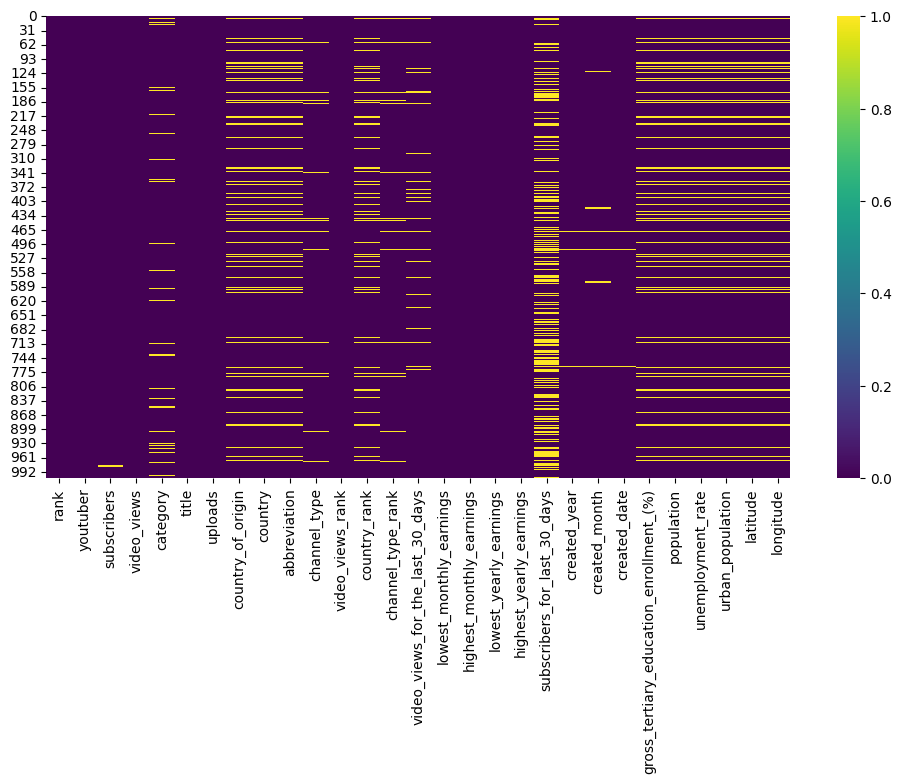

In [156]:
#Visualize missing values
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(),cbar=True,cmap='viridis')

In [157]:
#Missing value imputation for columns with missing values
# Select all numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Impute missing values in numerical columns with the mean
for col in numerical_cols:
    df[col].fillna(df[col].mean(), inplace=True)
# Impute missing values in categorical columns with the mode
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)
# Verify that there are no more missing values
print("\nMissing value percentages after imputation:")
print(df.isnull().sum()/len(df) * 100)



Missing value percentages after imputation:
rank                                       0.0
youtuber                                   0.0
subscribers                                0.0
video_views                                0.0
category                                   0.0
title                                      0.0
uploads                                    0.0
country_of_origin                          0.0
country                                    0.0
abbreviation                               0.0
channel_type                               0.0
video_views_rank                           0.0
country_rank                               0.0
channel_type_rank                          0.0
video_views_for_the_last_30_days           0.0
lowest_monthly_earnings                    0.0
highest_monthly_earnings                   0.0
lowest_yearly_earnings                     0.0
highest_yearly_earnings                    0.0
subscribers_for_last_30_days               0.0
created_year   

<Axes: >

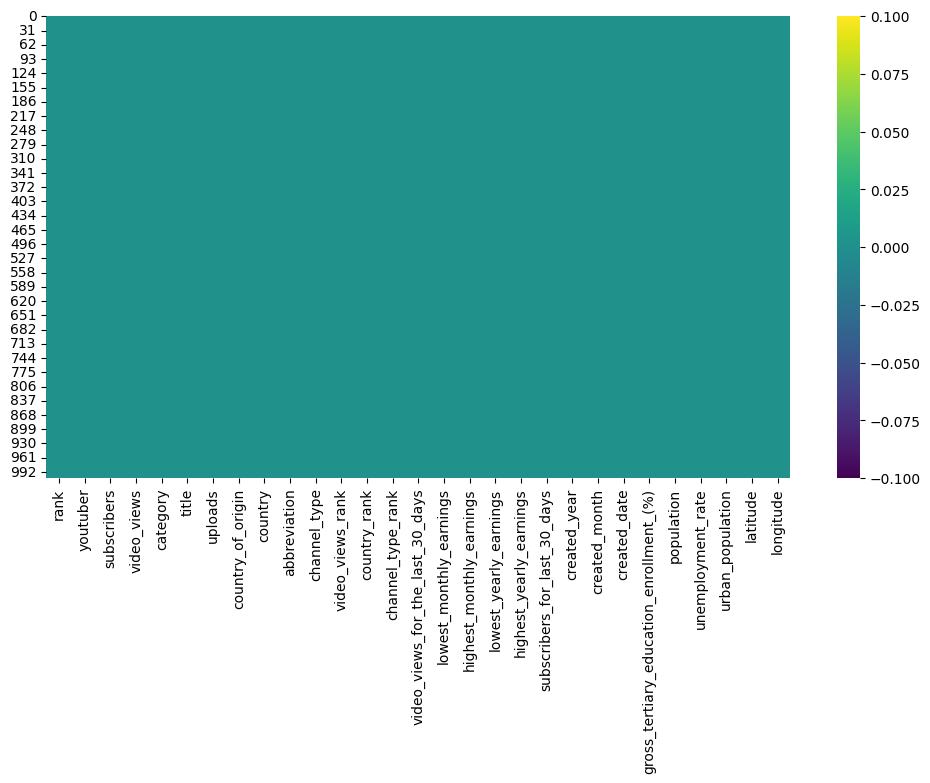

In [158]:
#Visualize missing values
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(),cbar=True,cmap='viridis')

In [159]:
# To get statistical summary of numerical columns
df.describe()

,rank,subscribers,video_views,uploads,video_views_rank,country_rank,channel_type_rank,video_views_for_the_last_30_days,lowest_monthly_earnings,highest_monthly_earnings,...,highest_yearly_earnings,subscribers_for_last_30_days,created_year,created_date,gross_tertiary_education_enrollment_(%),population,unemployment_rate,urban_population,latitude,longitude
count,1006.000000,1.006000e+03,1.006000e+03,1006.000000,1.006000e+03,1006.000000,1006.000000,1.006000e+03,1006.000000,1.006000e+03,...,1.006000e+03,1.006000e+03,1006.000000,1006.000000,1006.000000,1.006000e+03,1006.000000,1.006000e+03,1006.000000,1006.000000
mean,497.472167,2.319501e+07,1.112411e+10,9168.335984,5.607670e+05,384.289741,742.311020,1.760978e+08,37034.348489,5.922453e+05,...,7.110327e+06,3.495419e+05,2012.613387,15.712288,63.597273,4.304586e+08,9.258966,2.239747e+08,26.639994,-13.811287
std,288.738758,1.780383e+07,1.424148e+10,34028.189437,1.368205e+06,1152.406538,1904.078945,4.033444e+08,71869.653679,1.148967e+06,...,1.379921e+07,4.987677e+05,4.502888,8.743278,24.404935,4.428744e+08,4.573118,1.449939e+08,19.186892,79.239644
min,1.000000,1.230000e+07,0.000000e+00,0.000000,1.000000e+00,1.000000,1.000000,1.000000e+00,0.000000,0.000000e+00,...,0.000000e+00,1.000000e+00,1970.000000,1.000000,7.600000,2.025060e+05,0.750000,3.558800e+04,-38.416097,-172.104629
25%,247.250000,1.450000e+07,4.281427e+09,194.000000,3.230000e+02,14.000000,27.250000,2.226950e+07,2700.000000,4.340000e+04,...,5.207500e+05,1.000000e+05,2009.000000,8.000000,40.200000,1.260140e+08,5.360000,1.026269e+08,20.593684,-95.712891
50%,498.500000,1.775000e+07,7.751292e+09,726.500000,9.200000e+02,75.000000,69.000000,7.394550e+07,13250.000000,2.117000e+05,...,2.550000e+06,3.495419e+05,2013.000000,16.000000,63.597273,3.282395e+08,9.258966,2.239747e+08,26.639994,-13.811287
75%,748.750000,2.470000e+07,1.357357e+10,2606.500000,3.678750e+03,156.750000,145.000000,1.760978e+08,38125.000000,6.101750e+05,...,7.300000e+06,3.495419e+05,2016.000000,23.000000,88.200000,4.304586e+08,14.700000,2.706630e+08,37.090240,78.962880
max,995.000000,2.450000e+08,2.280000e+11,301308.000000,4.057944e+06,7741.000000,7741.000000,6.589000e+09,850900.000000,1.360000e+07,...,1.634000e+08,8.000000e+06,2022.000000,31.000000,113.100000,1.397715e+09,14.720000,8.429340e+08,61.924110,138.252924


In [160]:
#convert 'created date and created year' to integer type
df['created_date'] = df['created_date'].astype(int)
df['created_year'] = df['created_year'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1006 entries, 0 to 1005
Data columns (total 29 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   rank                                     1006 non-null   int64  
 1   youtuber                                 1006 non-null   object 
 2   subscribers                              1006 non-null   float64
 3   video_views                              1006 non-null   float64
 4   category                                 1006 non-null   object 
 5   title                                    1006 non-null   object 
 6   uploads                                  1006 non-null   int64  
 7   country_of_origin                        1006 non-null   object 
 8   country                                  1006 non-null   object 
 9   abbreviation                             1006 non-null   object 
 10  channel_type                             1006 no

### Top 10 Youtube channels based on No. of subscribers

Top 10 YouTube channels based on subscribers:
                     youtuber  subscribers        country
0                    T-Series  245000000.0          india
1              YouTube Movies  170000000.0  United States
2                     MrBeast  166000000.0  United States
3  Cocomelon - Nursery Rhymes  162000000.0  United States
4                   SET India  159000000.0          India
5                       Music  119000000.0  United States
6         ýýý Kids Diana Show  112000000.0  United States
7                   PewDiePie  111000000.0          Japan
8                 Like Nastya  106000000.0         Russia
9               Vlad and Niki   98900000.0  United States


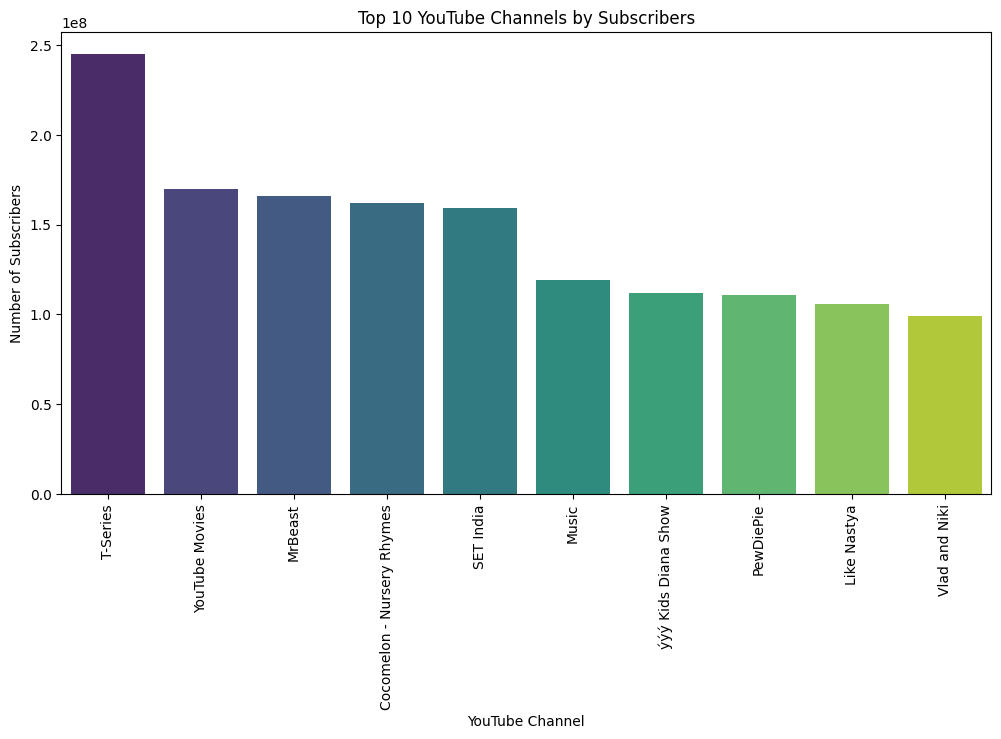

In [161]:
# What are the top 10 YouTube channels based on the number of subscribers?
top_channels=df.sort_values(by='subscribers',ascending=False).head(10)
print("Top 10 YouTube channels based on subscribers:")
print(top_channels[['youtuber','subscribers','country']])
#Visualize Top 10 youtube channels based on subscribers
plt.figure(figsize=(12,6))
sns.barplot(data=top_channels,x='youtuber',y='subscribers',palette='viridis')
plt.title('Top 10 YouTube Channels by Subscribers')
plt.xticks(rotation=90)
plt.xlabel('YouTube Channel')
plt.ylabel('Number of Subscribers')
plt.show()

### Highest average no. of subscribers by category

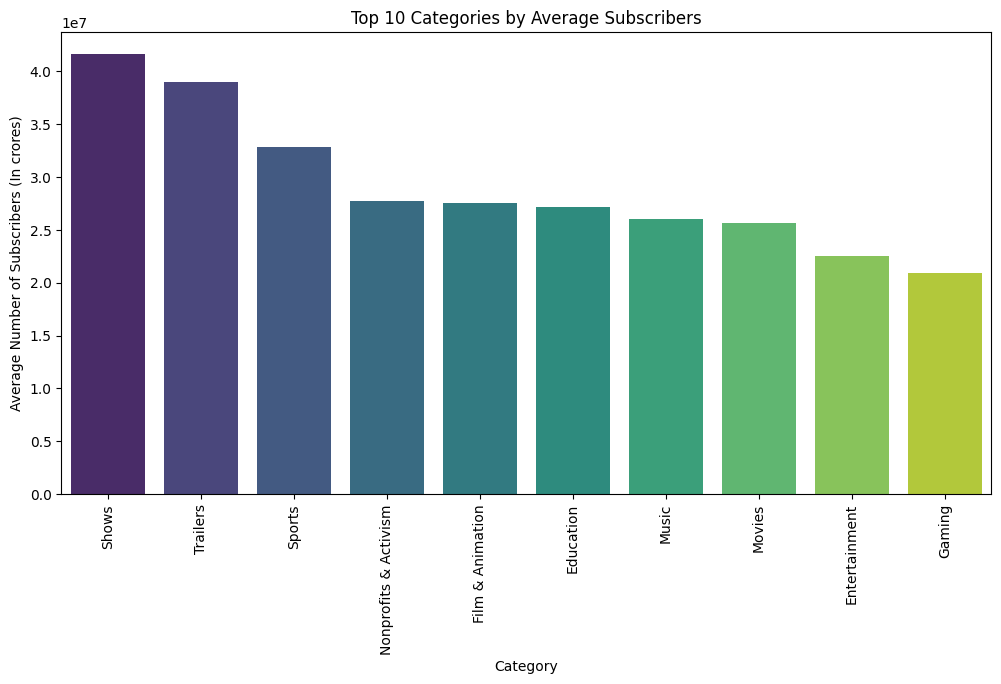

In [162]:
## Highest average no. of subscribers by category
avg_subscribers_by_category=df.groupby('category')['subscribers'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=avg_subscribers_by_category.index, y=avg_subscribers_by_category.values, palette='viridis')
plt.title('Top 10 Categories by Average Subscribers')
plt.xlabel('Category')
plt.ylabel('Average Number of Subscribers (In crores)')
plt.xticks(rotation=90)
plt.show()

### No. of videos in each category

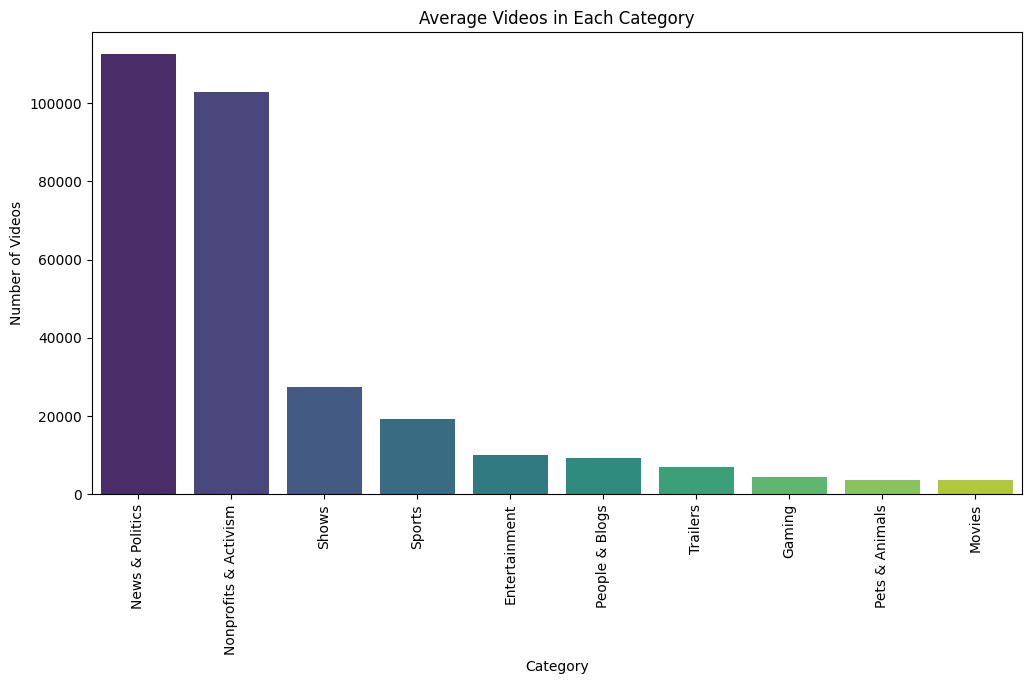

In [163]:
# Total No. of videos in each category
AVG_videos_by_category=df.groupby('category')['uploads'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=AVG_videos_by_category.index, y=AVG_videos_by_category.values, palette='viridis')
plt.title('Average Videos in Each Category')
plt.xlabel('Category')
plt.ylabel('Number of Videos')
plt.xticks(rotation=90)
plt.show()

### Top 5 countries based on no. of channels

Total countries in the dataset: 50


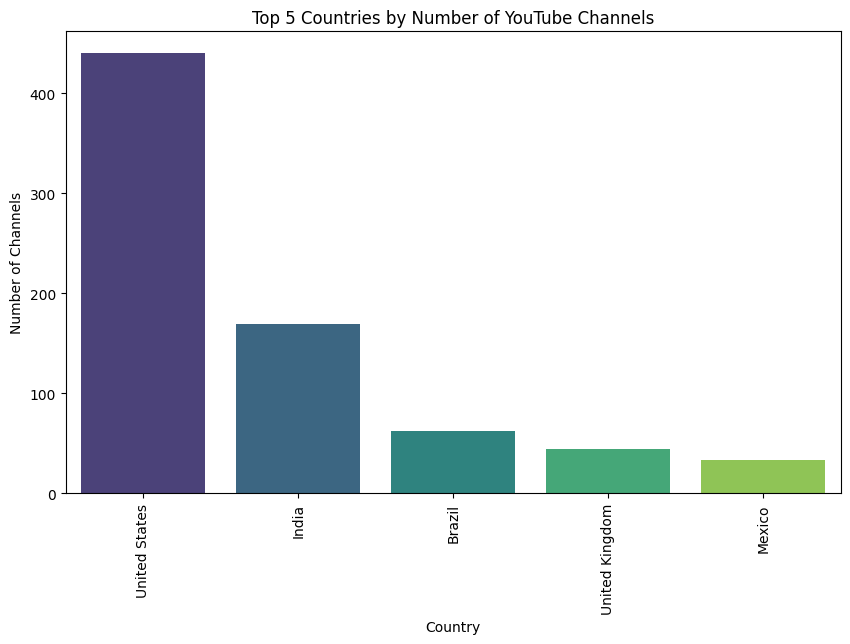

In [164]:
# Total countries in the dataset
total_countries=df['country'].nunique()
print(f'Total countries in the dataset: {total_countries}')
# Plot top 5 countries by number of channels
top_countries=df['country'].value_counts().head(5)
plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.index, y=top_countries.values, palette='viridis')   
plt.title('Top 5 Countries by Number of YouTube Channels')
plt.xlabel('Country')
plt.ylabel('Number of Channels')
plt.xticks(rotation=90) 
plt.show()

### Distribution of channel type across different categories

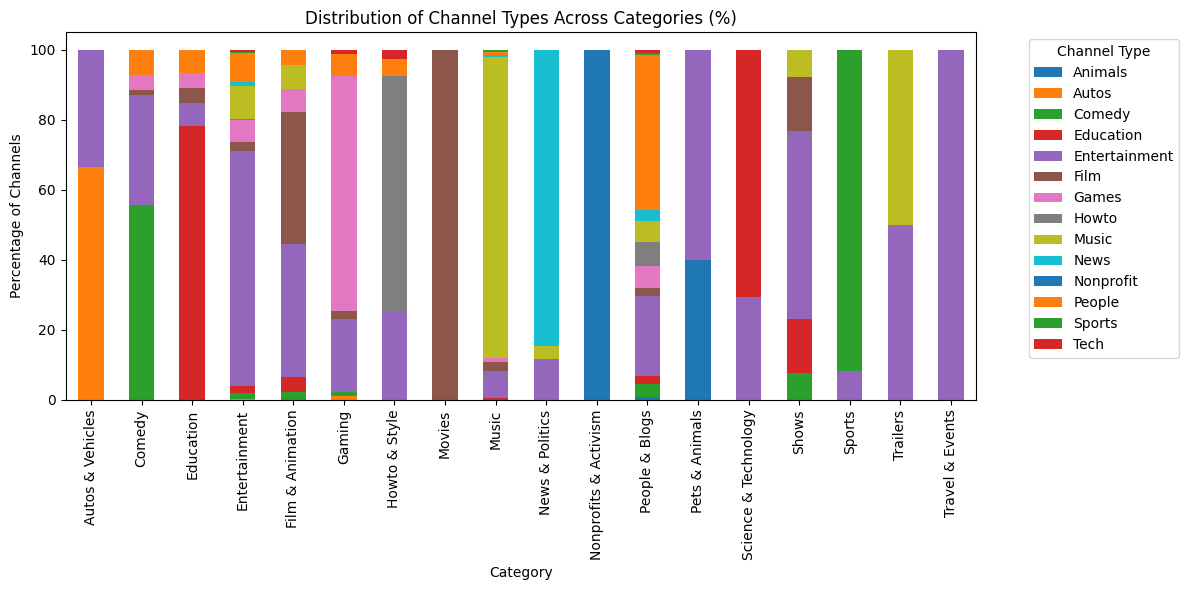

In [165]:
cross_tab = pd.crosstab(df['category'], df['channel_type'], normalize='index') * 100

cross_tab.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Distribution of Channel Types Across Categories (%)")
plt.ylabel("Percentage of Channels")
plt.xlabel("Category")
plt.legend(title="Channel Type", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


### Correlation between no. of subscribers and total video views

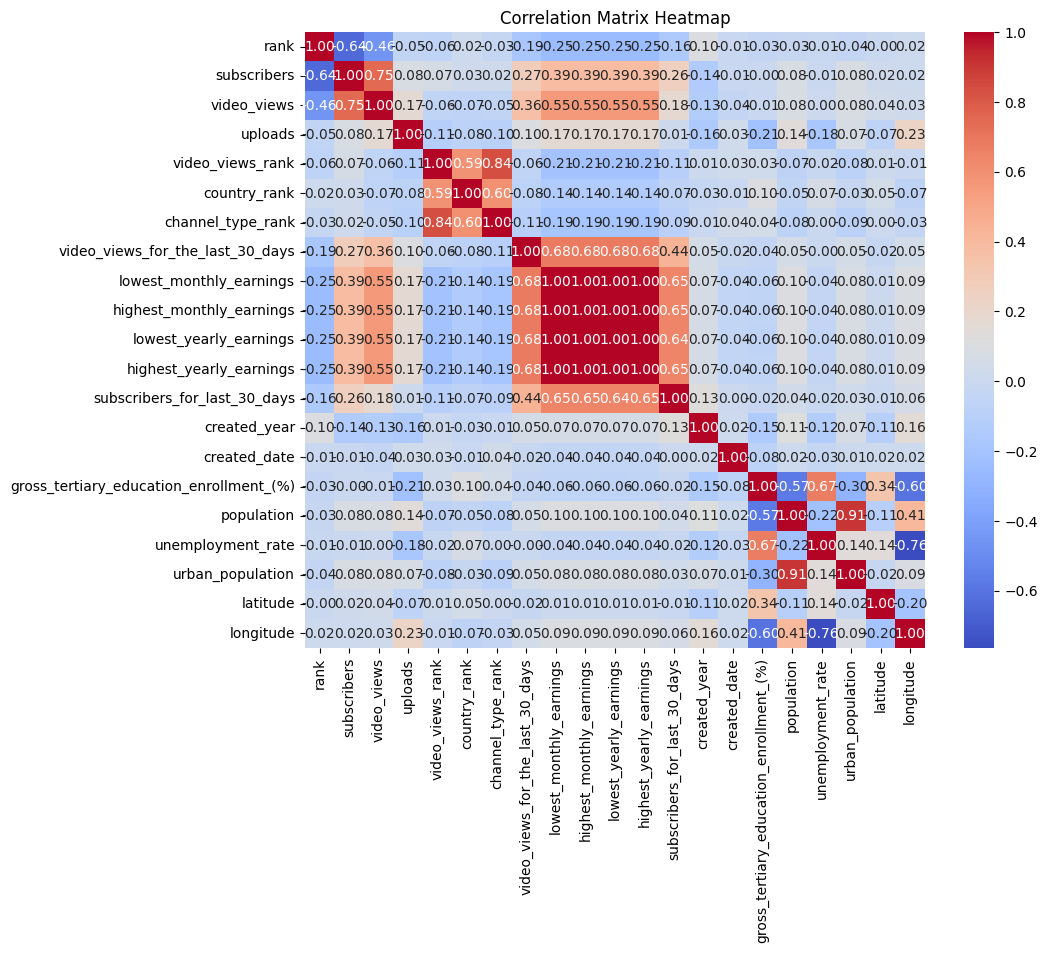

In [166]:
## Correlation matrix heatmap
plt.figure(figsize=(10,8))
numerical_cols = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix=numerical_cols.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

In [167]:
## Correlation between subscribers and views
corr_subs_views=df['subscribers'].corr(df['video_views'])
print(f'Correlation between subscribers and views: {corr_subs_views:.2f}')

Correlation between subscribers and views: 0.75


### Monthly earning across different categories

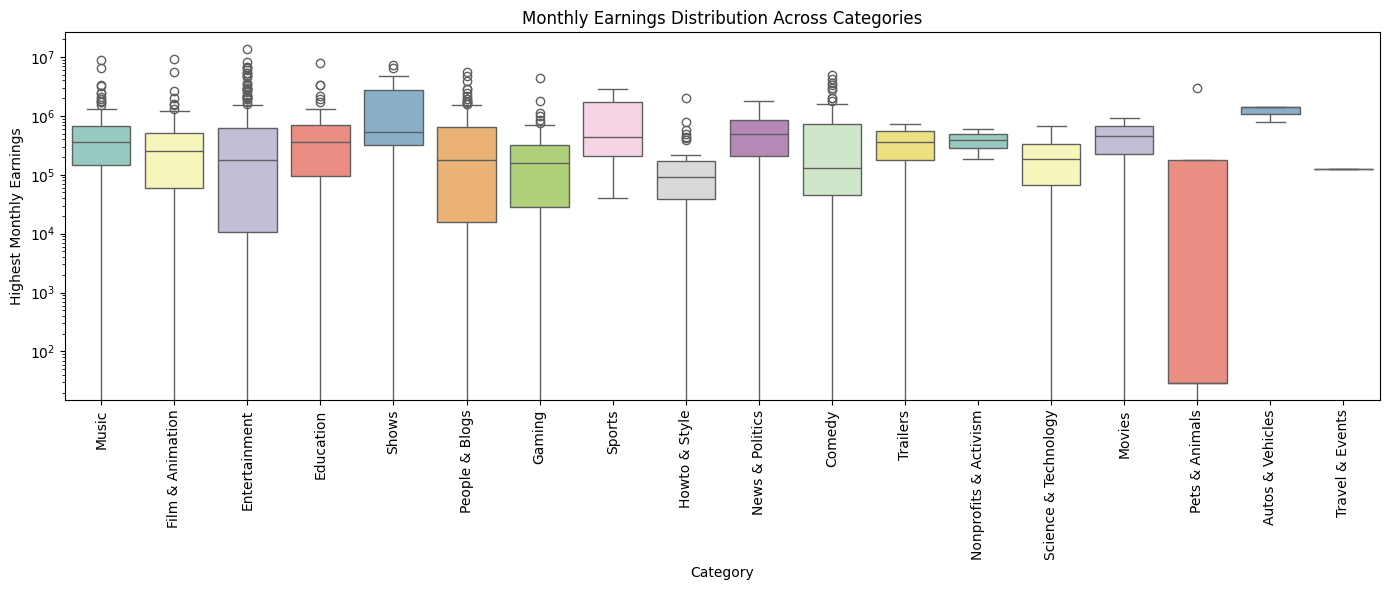

In [168]:
## See the boxplot of highest and lowest monthly earnings across different categories
plt.figure(figsize=(14,6))

sns.boxplot(
    x='category',
    y='highest_monthly_earnings',
    data=df,
    palette='Set3'
)

plt.title("Monthly Earnings Distribution Across Categories")
plt.xlabel("Category")
plt.ylabel("Highest Monthly Earnings")
plt.xticks(rotation=90)
plt.yscale('log')  # Use logarithmic scale for better visualization
plt.tight_layout()
plt.show()



### Distribution of subscribers

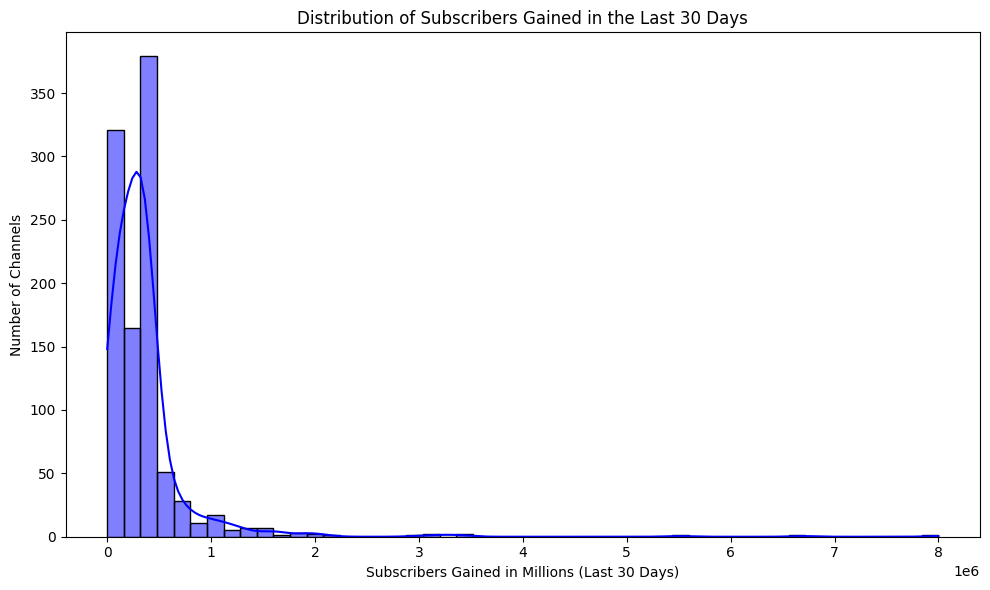

In [169]:
# Trend in subscribers gained in the last 30 days across all channels 
plt.figure(figsize=(10,6))

sns.histplot(df['subscribers_for_last_30_days'],bins=50,kde=True,color='blue')

plt.title("Distribution of Subscribers Gained in the Last 30 Days")
plt.xlabel("Subscribers Gained in Millions (Last 30 Days)")
plt.ylabel("Number of Channels")

plt.tight_layout()
plt.show()



### Outlier Earners

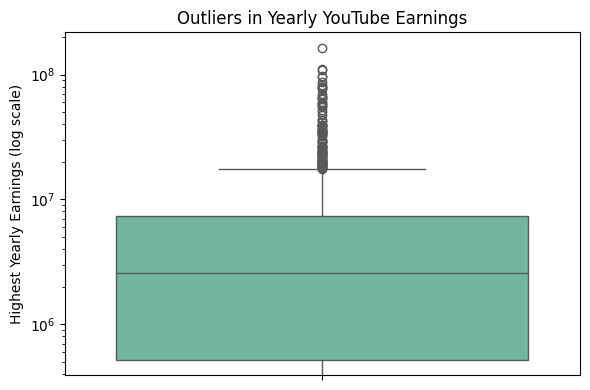

In [170]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['highest_yearly_earnings'],palette='Set2')
plt.yscale('log')  
plt.title("Outliers in Yearly YouTube Earnings")
plt.ylabel("Highest Yearly Earnings (log scale)")
plt.tight_layout()
plt.show()


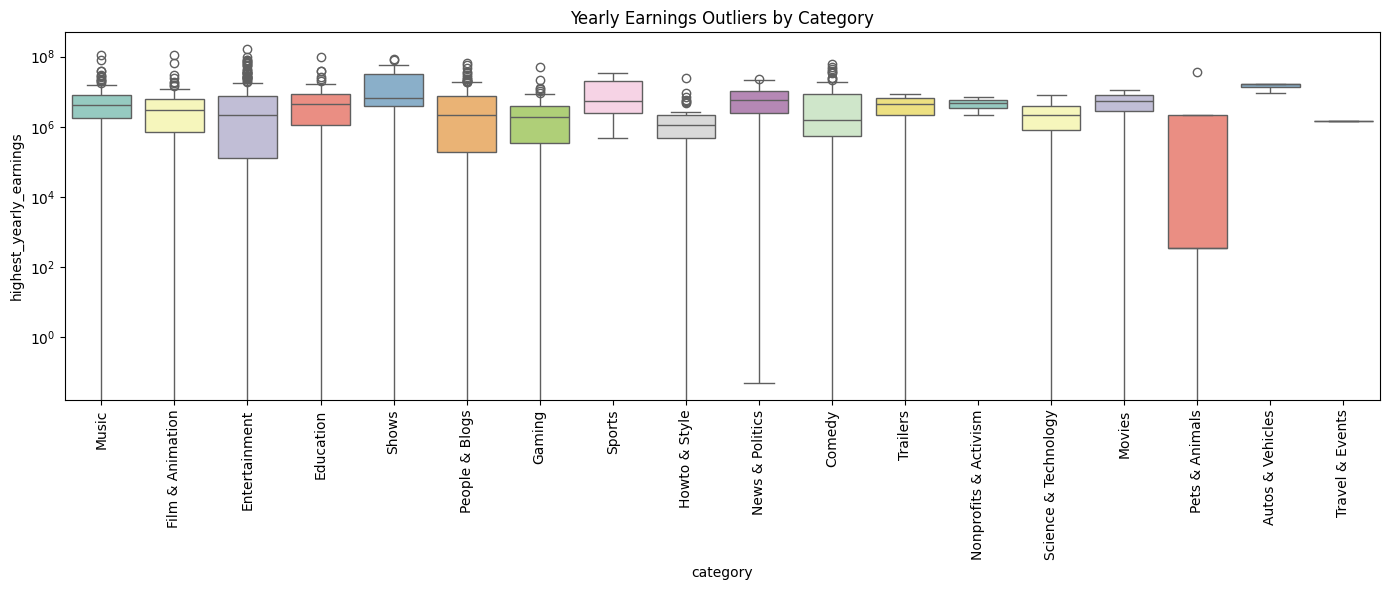

In [171]:
## Identify outliers in yearly earnings across different categories
plt.figure(figsize=(14,6))
sns.boxplot(x='category',y='highest_yearly_earnings',data=df,palette='Set3')
plt.yscale('log')
plt.xticks(rotation=90)
plt.title("Yearly Earnings Outliers by Category")
plt.tight_layout()
plt.show()


### Trend in Youtube channel creation 

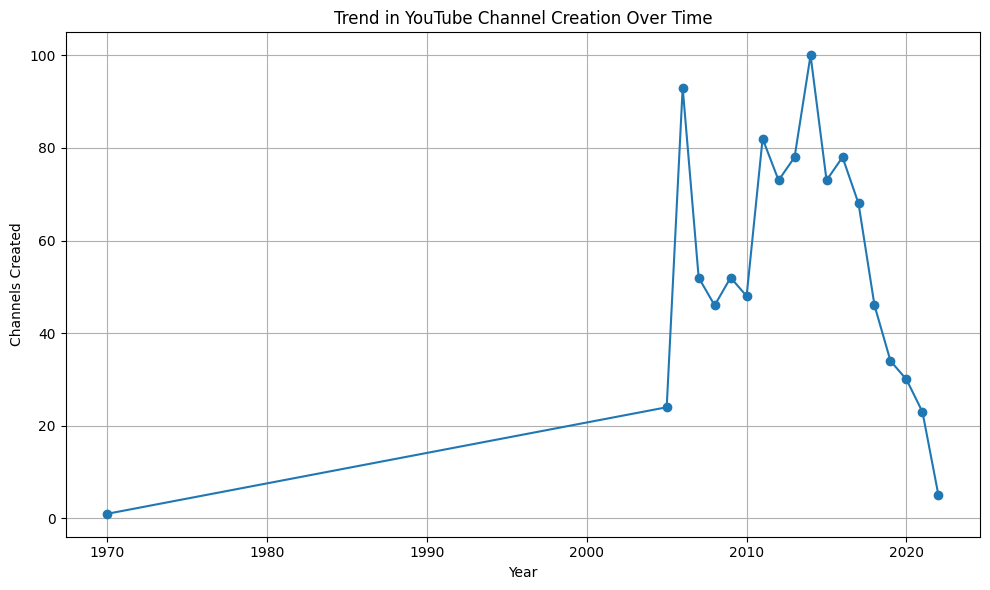

In [172]:
channels_per_year = df['created_year'].value_counts().sort_index()

plt.figure(figsize=(10,6))
plt.plot(channels_per_year.index, channels_per_year.values, marker='o')

plt.title("Trend in YouTube Channel Creation Over Time")
plt.xlabel("Year")
plt.ylabel("Channels Created")
plt.grid(True)
plt.tight_layout()
plt.show()


### Relationship between education and Youtube channels

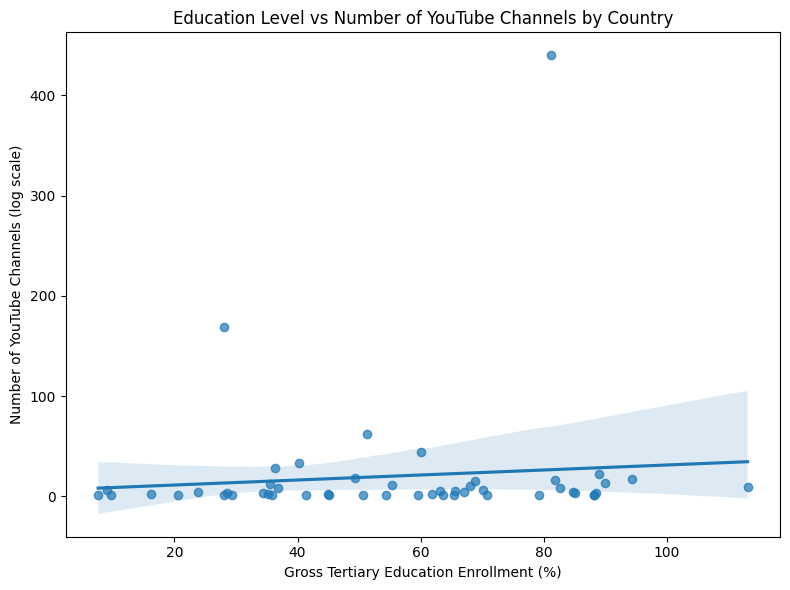

In [173]:
country_channels = (
    df.groupby('country')
      .agg(
          channel_count=('youtuber', 'count'),
          tertiary_enrollment=('gross_tertiary_education_enrollment_(%)', 'mean')
      )
      .dropna()
)

plt.figure(figsize=(8,6))

sns.regplot(
    x='tertiary_enrollment',
    y='channel_count',
    data=country_channels,
    scatter_kws={'alpha':0.7}
)

plt.xlabel("Gross Tertiary Education Enrollment (%)")
plt.ylabel("Number of YouTube Channels (log scale)")
plt.title("Education Level vs Number of YouTube Channels by Country")
plt.tight_layout()
plt.show()

In [174]:
## correlation between tertiary enrollment and channel count
corr_tertiary_channel_count = country_channels['tertiary_enrollment'].corr(country_channels['channel_count'])
print(f'Correlation between tertiary enrollment and channel count: {corr_tertiary_channel_count:.2f}')

## Low education but high number of channels shows population effects (Outliers)

Correlation between tertiary enrollment and channel count: 0.10


### Unemployment and No. of channels

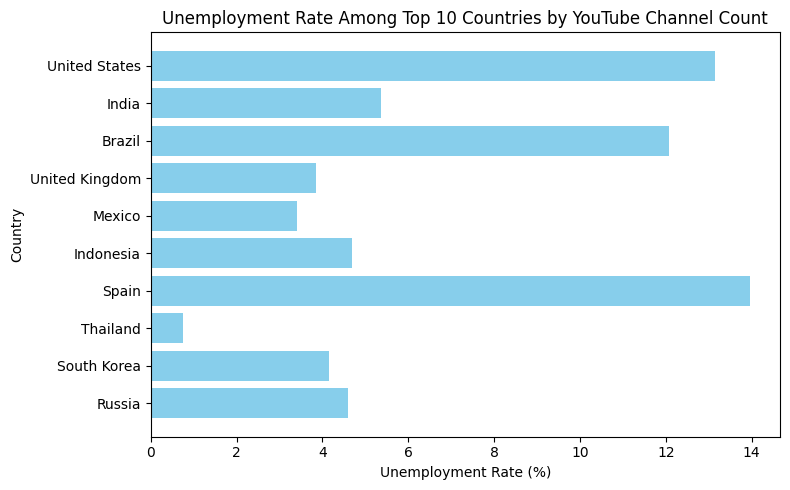

In [175]:
top_countries = (
    df.groupby('country')
      .agg(
          channel_count=('youtuber', 'count'),
          unemployment_rate=('unemployment_rate', 'mean')
      )
      .sort_values('channel_count', ascending=False)
      .head(10)
)
plt.figure(figsize=(8,5))
plt.barh(top_countries.index, top_countries['unemployment_rate'], color='skyblue')
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Country")
plt.title("Unemployment Rate Among Top 10 Countries by YouTube Channel Count")
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()

### Average Urban population

In [176]:
country_urban = (
    df[['country', 'urban_population']]
    .drop_duplicates()
    .dropna()
)
avg_urban_population = country_urban['urban_population'].mean()
print("Average Urban Population:",avg_urban_population)


Average Urban Population: 83648336.7184492


### Urban Population among top 10 countries 

In [177]:
avg_urban_population=df.groupby('country').agg(channel_count=('youtuber', 'count'),urban_population=('urban_population','mean')).sort_values('channel_count', ascending=False).head(10)
avg_urban_population

,channel_count,urban_population
country,,
United States,440,2.573993e+08
India,169,4.710315e+08
Brazil,62,1.832416e+08
United Kingdom,44,5.590832e+07
Mexico,33,1.026269e+08
Indonesia,28,1.515097e+08
Spain,22,3.792741e+07
Thailand,18,3.529460e+07
South Korea,17,4.210672e+07


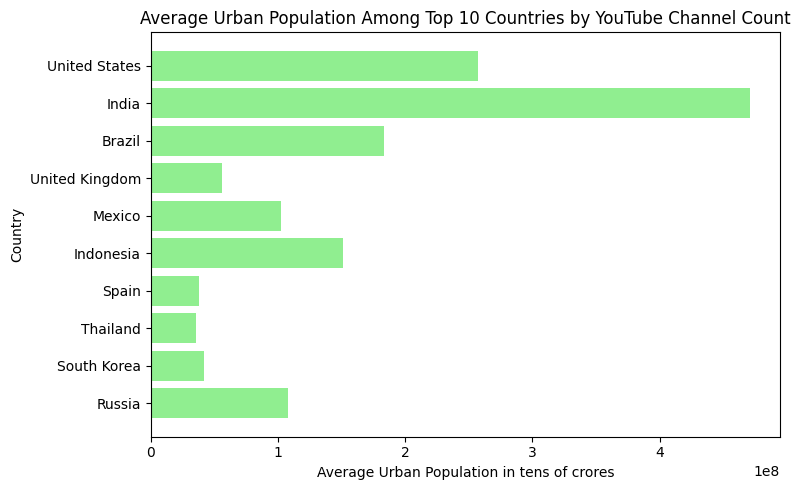

In [178]:
plt.figure(figsize=(8,5))
plt.barh(avg_urban_population.index,avg_urban_population['urban_population'],color='lightgreen')
plt.xlabel("Average Urban Population in tens of crores")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.title("Average Urban Population Among Top 10 Countries by YouTube Channel Count")
plt.tight_layout()
plt.show()

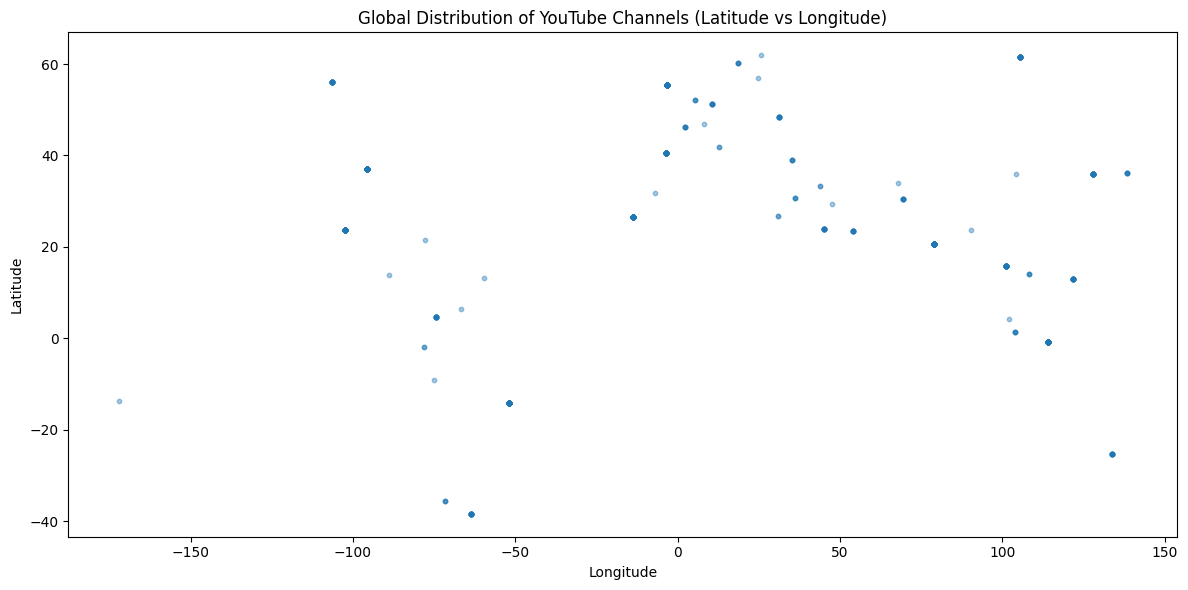

In [179]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.scatter(
    df['longitude'],
    df['latitude'],
    alpha=0.4,
    s=10
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Global Distribution of YouTube Channels (Latitude vs Longitude)")
plt.tight_layout()
plt.show()


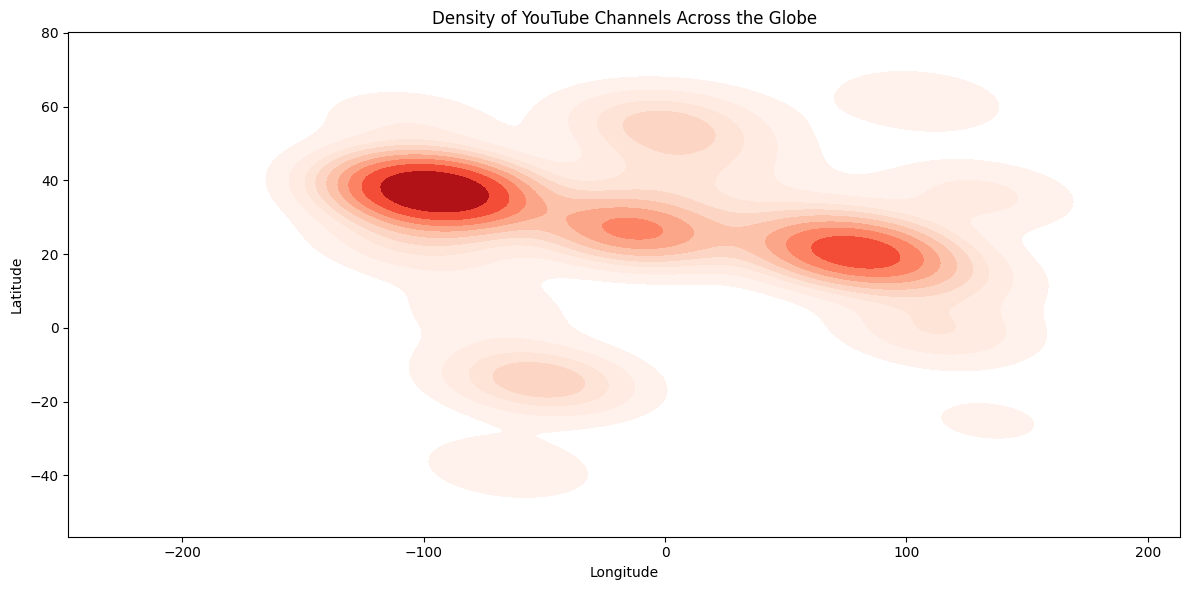

In [180]:
import seaborn as sns

plt.figure(figsize=(12,6))

sns.kdeplot(
    x=df['longitude'],
    y=df['latitude'],
    cmap="Reds",
    fill=True,
    thresh=0.05
)

plt.title("Density of YouTube Channels Across the Globe")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()


In [181]:
## Correkation between No. of subscribers and Population of the country
Pop_corr_subs = df['subscribers'].corr(df['population'])
print(f'Correlation between No. of subscribers and Population of the country: {Pop_corr_subs:.2f}')

Correlation between No. of subscribers and Population of the country: 0.08


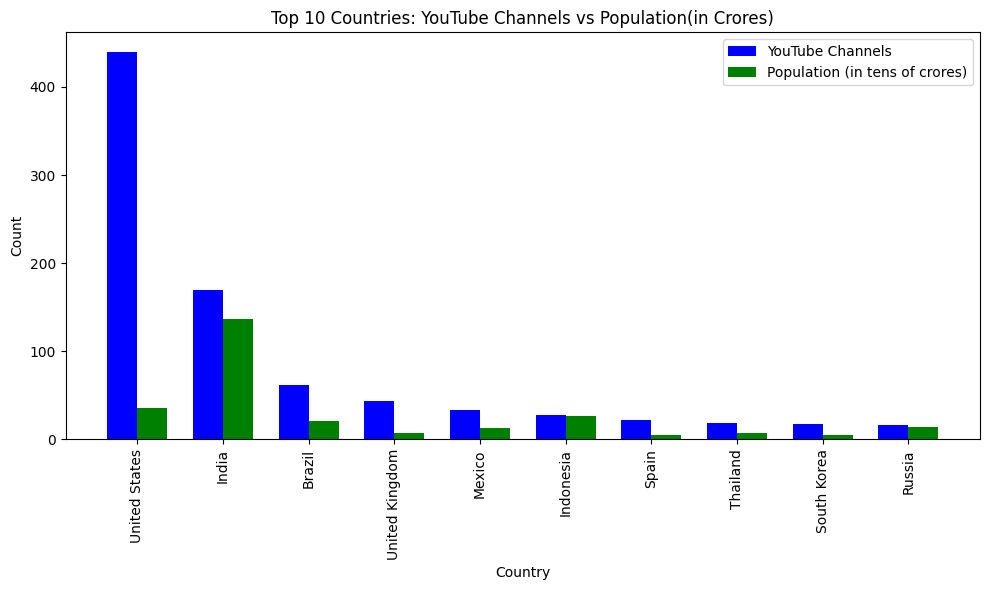

In [182]:
## Comparison of Top 10 countriws with highest no. of youtube channels with their total population
top_countries = (
    df.groupby('country')
      .agg(
          channel_count=('youtuber', 'count'),
            population=('population', 'mean')
      )
      .sort_values('channel_count', ascending=False)
      .head(10)
)
plt.figure(figsize=(10,6))
bar_width = 0.35
indices = np.arange(len(top_countries))
plt.bar(indices, top_countries['channel_count'], width=bar_width, label='YouTube Channels', color='b')
plt.bar(indices + bar_width, top_countries['population']/1e7, width=bar_width, label='Population (in tens of crores)', color='g')
plt.xlabel("Country")
plt.ylabel("Count")
plt.title("Top 10 Countries: YouTube Channels vs Population(in Crores)")
plt.xticks(indices + bar_width / 2, top_countries.index, rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

In [183]:
## Correlation between no. of subscribers gained in last 30 days and unemployment rate of a country
Unemp_subs_30days_correlation = df['subscribers_for_last_30_days'].corr(df['unemployment_rate'])
print(f'Correlation between no. of subscribers gained in last 30 days and unemployment rate of a country: {Unemp_subs_30days_correlation:.2f}')


Correlation between no. of subscribers gained in last 30 days and unemployment rate of a country: -0.02


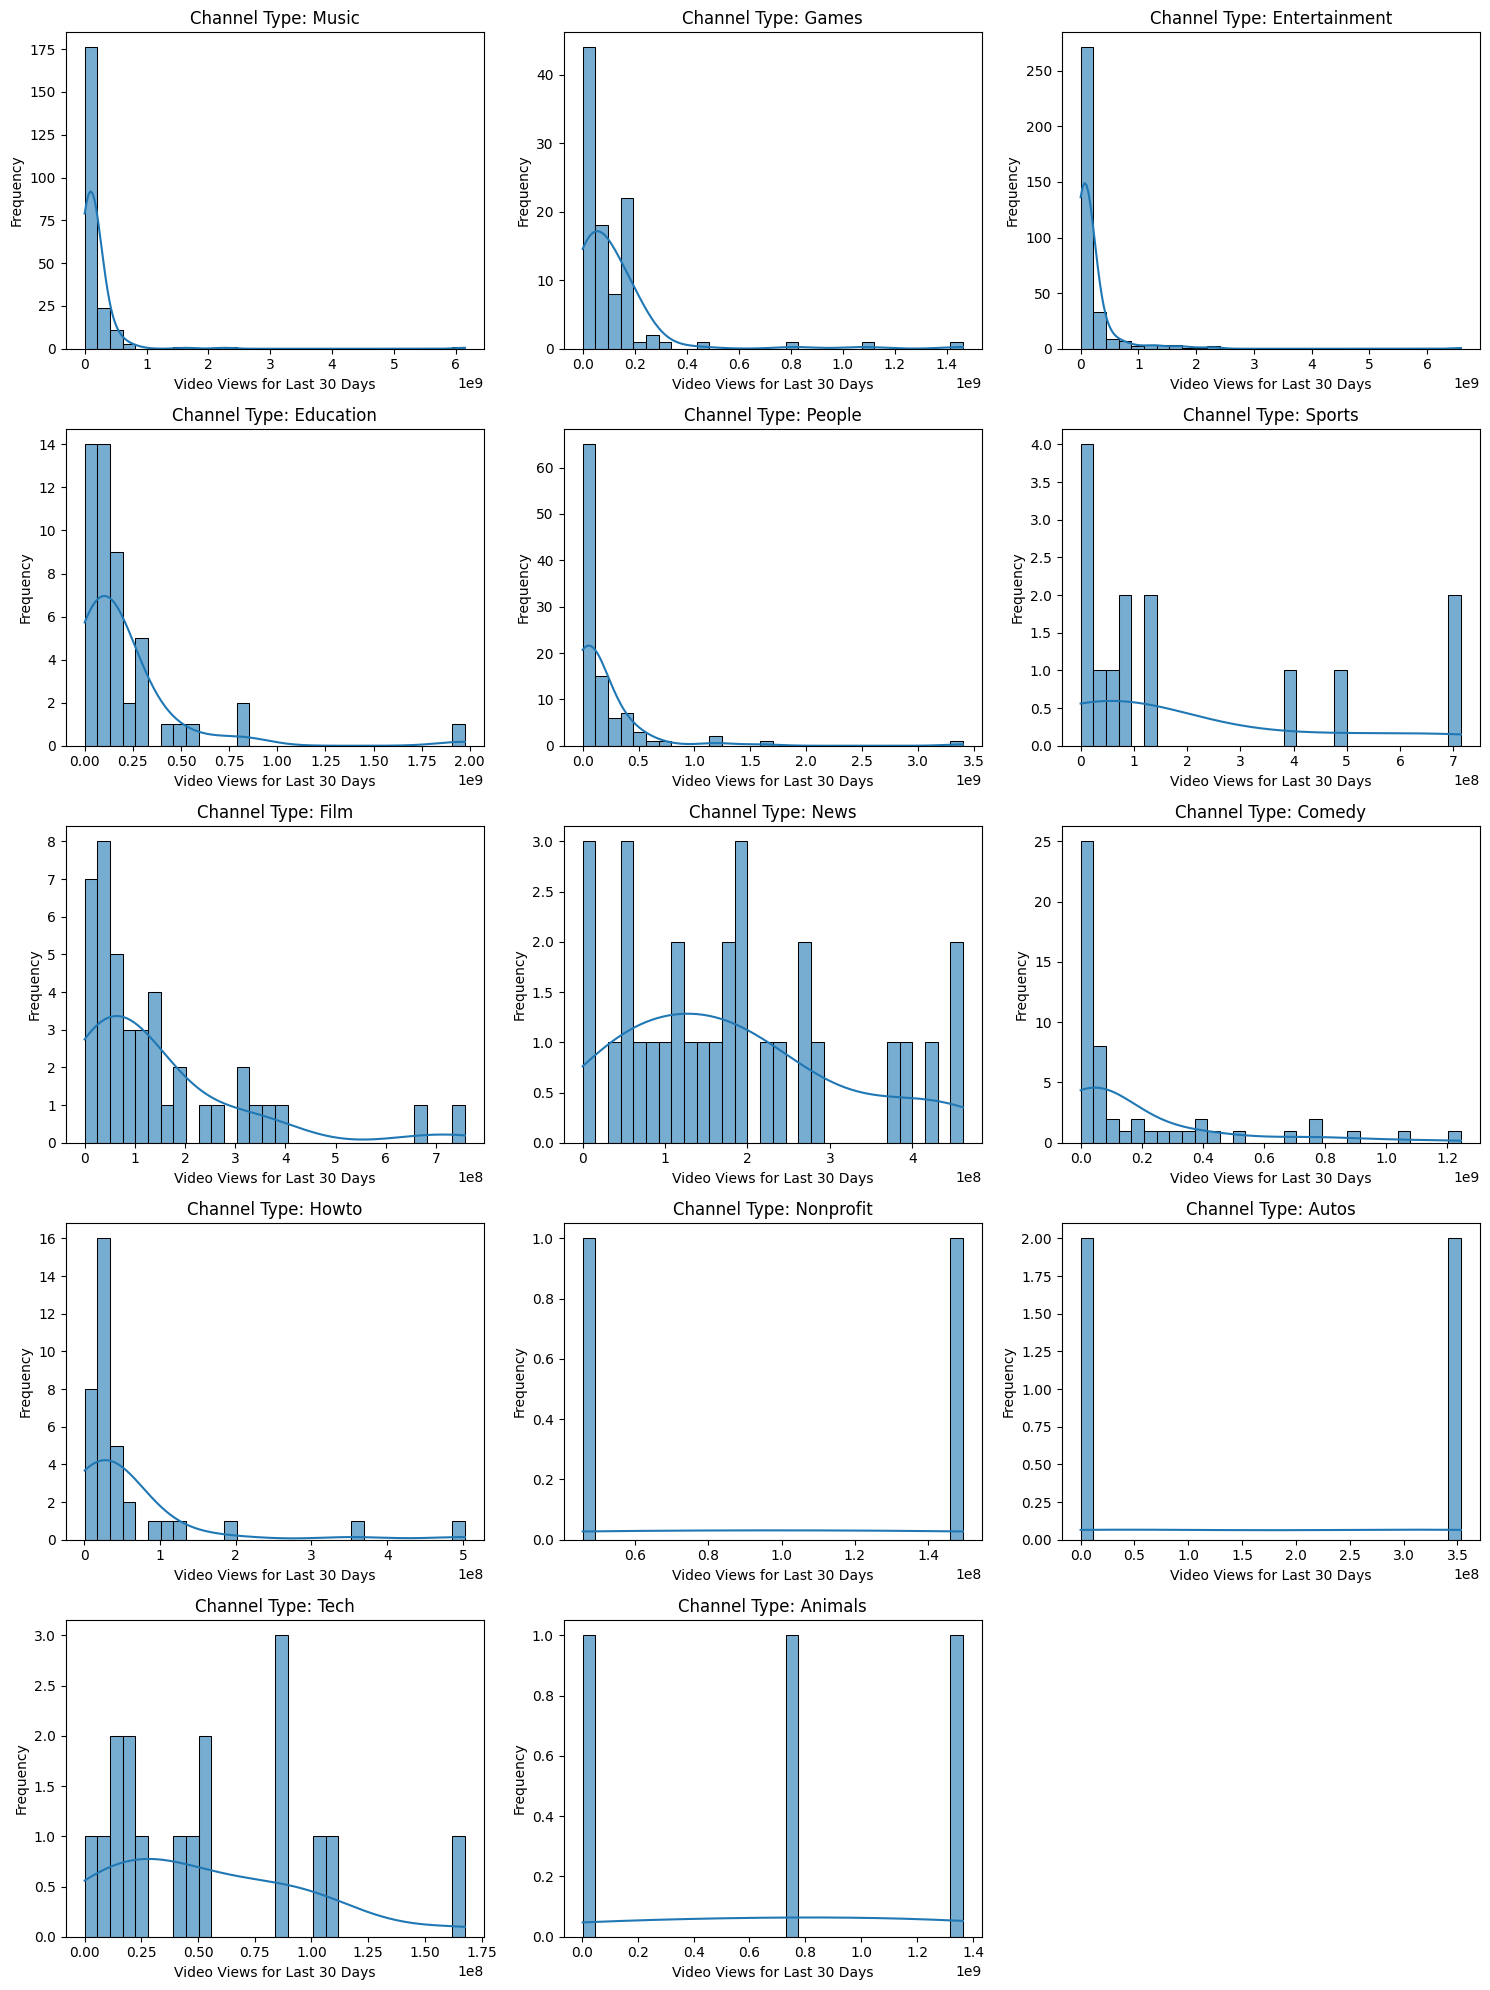

In [184]:
# Distribution of video views for last 30 days across different channel types
# Histogram Plots for each channel type
cols=3
rows=math.ceil(len(df['channel_type'].unique())/cols)
fig,axes=plt.subplots(rows,cols,figsize=(5*cols,4*rows))
axes=axes.flatten()
for i,channel_type in enumerate(df['channel_type'].unique()):
        subset = df[df['channel_type'] == channel_type]
        sns.histplot(subset['video_views_for_the_last_30_days'], bins=30, kde=True, label=channel_type, alpha=0.6,ax=axes[i])
        axes[i].set_title(f'Channel Type: {channel_type}')
        axes[i].set_xlabel('Video Views for Last 30 Days')
        axes[i].set_ylabel('Frequency')
        
# Remove empty subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


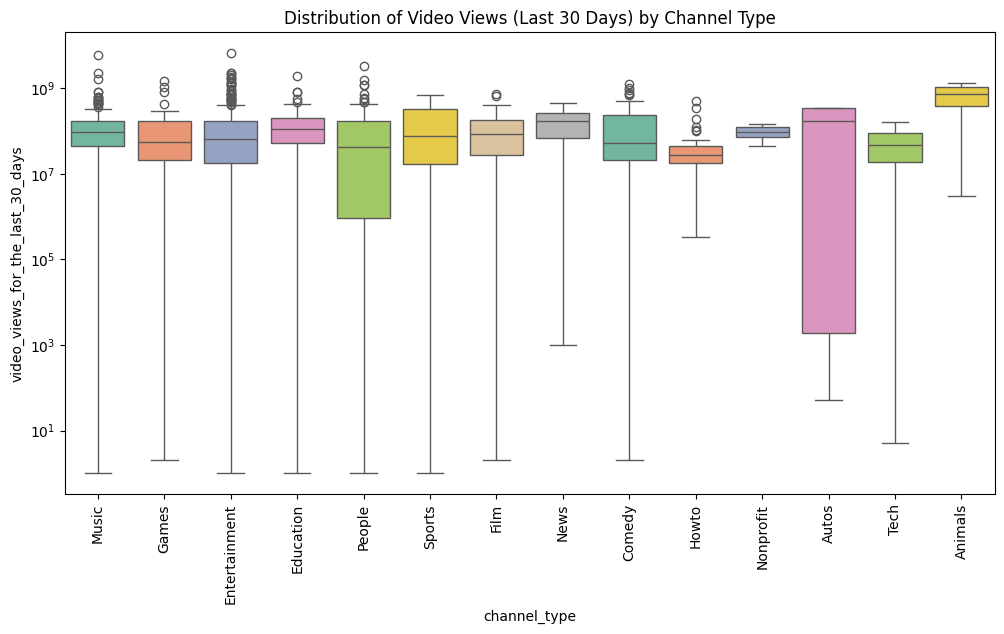

In [185]:
plt.figure(figsize=(12,6))
sns.boxplot(
    x='channel_type',
    y='video_views_for_the_last_30_days',
    data=df,
    palette='Set2'
)
plt.yscale('log')  # optional but highly recommended
plt.title('Distribution of Video Views (Last 30 Days) by Channel Type')
plt.xticks(rotation=90)
plt.show()


In [186]:
df.head()

,rank,youtuber,subscribers,video_views,category,title,uploads,country_of_origin,country,abbreviation,...,subscribers_for_last_30_days,created_year,created_month,created_date,gross_tertiary_education_enrollment_(%),population,unemployment_rate,urban_population,latitude,longitude
0,1,T-Series,245000000.0,2.280000e+11,Music,T-Series,20082,India,india,IN,...,2.000000e+06,2006,Mar,13,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000.0,0.000000e+00,Film & Animation,youtubemovies,1,United States,United States,US,...,3.495419e+05,2006,Jan,5,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000.0,2.836884e+10,Entertainment,MrBeast,741,United States,United States,US,...,8.000000e+06,2012,Feb,20,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000.0,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,United States,US,...,1.000000e+06,2006,Sep,1,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000.0,1.480000e+11,Shows,SET India,116536,India,India,IN,...,1.000000e+06,2006,Sep,20,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [187]:
df['created_month'].unique()
df['created_month'] = (
    df['created_month']
    .astype(str)
    .str.strip()      # remove spaces
    .str.title()      # jan → Jan
)
df['upload_date'] = pd.to_datetime(
    df['created_date'].astype(str) + ' ' +
    df['created_month'] + ' ' +
    df['created_year'].astype(str),
    format='%d %b %Y',
    errors='coerce'
)
df.head()


,rank,youtuber,subscribers,video_views,category,title,uploads,country_of_origin,country,abbreviation,...,created_year,created_month,created_date,gross_tertiary_education_enrollment_(%),population,unemployment_rate,urban_population,latitude,longitude,upload_date
0,1,T-Series,245000000.0,2.280000e+11,Music,T-Series,20082,India,india,IN,...,2006,Mar,13,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880,2006-03-13
1,2,YouTube Movies,170000000.0,0.000000e+00,Film & Animation,youtubemovies,1,United States,United States,US,...,2006,Jan,5,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891,2006-01-05
2,3,MrBeast,166000000.0,2.836884e+10,Entertainment,MrBeast,741,United States,United States,US,...,2012,Feb,20,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891,2012-02-20
3,4,Cocomelon - Nursery Rhymes,162000000.0,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,United States,US,...,2006,Sep,1,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891,2006-09-01
4,5,SET India,159000000.0,1.480000e+11,Shows,SET India,116536,India,India,IN,...,2006,Sep,20,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880,2006-09-20


In [200]:

df['upload_date']=pd.to_datetime(df['upload_date'],errors='coerce')
df = df[df['upload_date'] >'1970-01-01']

df['month_year'] = df['upload_date'].dt.to_period('M')
monthly_uploads = df.groupby('month_year').size().reset_index(name='num_videos')
monthly_uploads['month_year'] = monthly_uploads['month_year'].dt.to_timestamp()
monthly_uploads=monthly_uploads.sort_values('month_year')


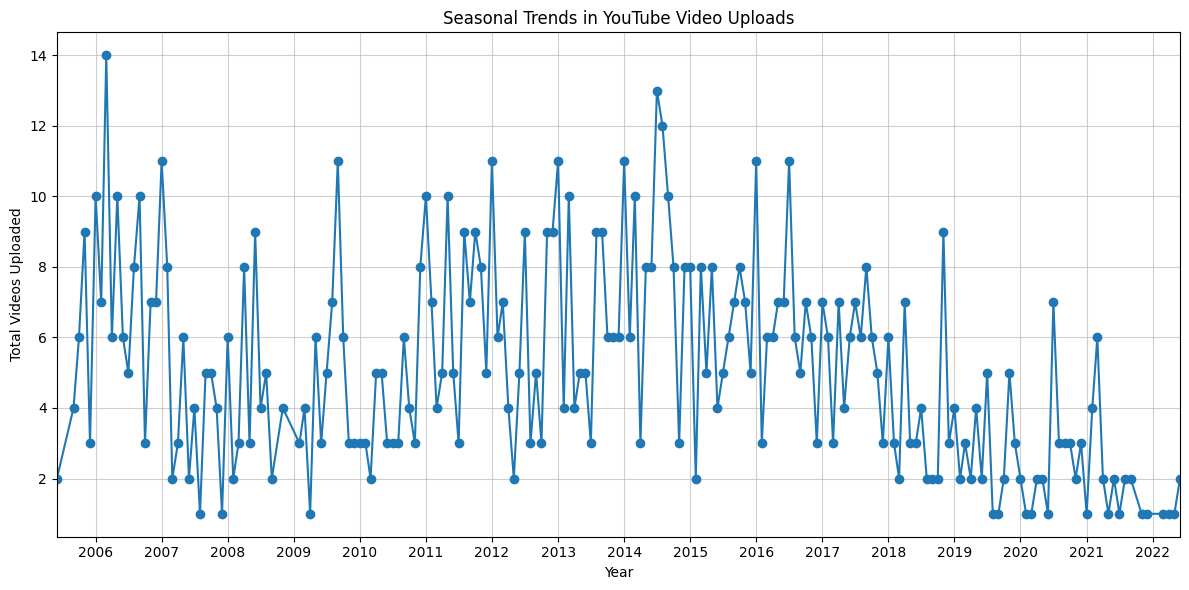

In [ ]:

## Seasonal trends in no. of videos uploaded by Youtube channels proxied using channel creation date because no. of videos are static
df['upload_date'] = pd.to_datetime(df['upload_date'], errors='coerce')
df = df[df['upload_date'] > '1970-01-01']

df['month_year'] = df['upload_date'].dt.to_period('M')
monthly_uploads = df.groupby('month_year').size().reset_index(name='num_videos')
monthly_uploads['month_year'] = monthly_uploads['month_year'].dt.to_timestamp()
monthly_uploads = monthly_uploads.sort_values('month_year')


fig, ax = plt.subplots(figsize=(12,6))

ax.plot(
    monthly_uploads['month_year'],
    monthly_uploads['num_videos'],
    marker='o'
)

ax.set_title("Seasonal Trends in YouTube Video Uploads")
ax.set_xlabel("Year")
ax.set_ylabel("Total Videos Uploaded")

ax.xaxis.set_major_locator(mdates.YearLocator()) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.set_xlim(
    monthly_uploads['month_year'].min(),
    monthly_uploads['month_year'].max()
)

ax.grid(True, which='major', alpha=0.6)
plt.tight_layout()
plt.show()


In [198]:
# To get the average no. of subscribers gained per month since the creation of youttube channels till now

current_date = pd.to_datetime('2024-06-01')
df['created_month'].unique()
df['created_month'] = (
    df['created_month']
    .astype(str)
    .str.strip()      # remove spaces
    .str.title()      # jan → Jan
)
df['Channel_date'] = pd.to_datetime(
    df['created_date'].astype(str) + ' ' +
    df['created_month'] + ' ' +
    df['created_year'].astype(str),
    format='%d %b %Y',
    errors='coerce'
)
df['months_since_creation'] = ((current_date - df['Channel_date']).dt.days) // 30
df['avg_subscribers_per_month'] = df['subscribers'] / df['months_since_creation']
df[['youtuber', 'subscribers', 'Channel_date', 'months_since_creation', 'avg_subscribers_per_month']].head()



,youtuber,subscribers,Channel_date,months_since_creation,avg_subscribers_per_month
0,T-Series,245000000.0,2006-03-13,221,1.108597e+06
1,YouTube Movies,170000000.0,2006-01-05,224,7.589286e+05
2,MrBeast,166000000.0,2012-02-20,149,1.114094e+06
3,Cocomelon - Nursery Rhymes,162000000.0,2006-09-01,216,7.500000e+05
4,SET India,159000000.0,2006-09-20,215,7.395349e+05
